# Multiplierless FIR Lowpass Filter Design

This notebook demonstrates multiplierless FIR filter design using:
1. **Spectral Factorization** - Convert magnitude design to FIR coefficients
2. **Ellipsoid Algorithm** - Optimization with cutting plane method
3. **CSD (Canonical Signed Digit)** - Multiplierless representation

## Background

FIR Filter Design via Spectral Factorization and Convex Optimization:
- Minimize max |H(w)| for w in stopband
- Subject to 1/delta <= |H(w)| <= delta for w in passband

## Dependencies
```bash
pip install numpy matplotlib scipy ellalgo multiplierless csdigit
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import remez, freqz, group_delay
from ellalgo.cutting_plane import Options, cutting_plane_optim, cutting_plane_optim_q
from ellalgo.ell import Ell
from multiplierless.spectral_fact import spectral_fact
from ellalgo.oracles.lowpass_oracle import create_lowpass_case
from multiplierless.lowpass_oracle_q import LowpassOracleQ
from csdigit.csd import to_csdnnz

import warnings

warnings.filterwarnings("ignore")

## Helper Functions

In [2]:
def create_csdlowpass_case(N=48, nnz=8):
    """
    Create a CSD lowpass filter design case.

    Parameters:
        N: Number of FIR coefficients
        nnz: Number of non-zeros (multiplierless constraint)

    Returns:
        Pcsd: Oracle for CSD-constrained design
        Spsq: Squared spectral factor
    """
    P = create_lowpass_case(N)
    Spsq = P.sp_sq
    Pcsd = LowpassOracleQ(nnz, P)
    return Pcsd, Spsq

In [3]:
def plot_lowpass_result(rf, Spsqf, rcsd, Spsqcsd):
    """
    Plot the designed filter responses.
    """
    # Compute spectral factorization
    h_spf = spectral_fact(rf)  # Regular spectral factorization
    h_spcsd = spectral_fact(rcsd)  # CSD-constrained

    # Compute the min attenuation in the stopband
    Ustop = 20 * np.log10(np.sqrt(Spsqf))
    print("Min attenuation in the stopband is ", Ustop, " dB.")

    # Reference: Remez algorithm filter
    freq = [0, 0.12, 0.2, 1.0]
    desired = [1, 0]
    h_linear = remez(151, freq, desired, fs=2.0)

    # Create plots
    fig = plt.figure(figsize=(12, 10))
    ax1 = fig.add_subplot(221)
    ax2 = fig.add_subplot(222)
    ax3 = fig.add_subplot(223)
    ax4 = fig.add_subplot(224)
    axs = (ax1, ax2, ax3, ax4)

    for h, style, color in zip((h_spcsd, h_spf), ("-", "-"), ("k", "r")):
        w, H = freqz(h)
        w, gd = group_delay((h, 1))
        w /= np.pi
        axs[0].plot(h, color=color, linestyle=style)
        axs[1].plot(w, np.abs(H), color=color, linestyle=style)
        axs[2].plot(w, 20 * np.log10(np.abs(H)), color=color, linestyle=style)
        axs[3].plot(w, gd, color=color, linestyle=style)

    for ax in axs:
        ax.grid(True, color="0.5")
        ax.fill_between(freq[1:3], *ax.get_ylim(), color="#ffeeaa", zorder=1)

    axs[0].set(xlim=[0, len(h_linear) - 1], ylabel="Amplitude", xlabel="Samples")
    axs[1].legend(["Our(csd)", "Our"], title="Phase")
    for ax, ylim in zip(axs[1:], ([0, 1.1], [-80, 10], [-60, 60])):
        ax.set(xlim=[0, 1], ylim=ylim, xlabel="Frequency")
    axs[1].set(ylabel="Magnitude")
    axs[2].set(ylabel="Magnitude (dB)")
    axs[3].set(ylabel="Group delay")
    plt.tight_layout()
    plt.show()

## Demo: Multiplierless FIR Filter Design

Design a lowpass FIR filter with:
- **N = 48** coefficients
- **nnz = 8** non-zero digits (multiplierless constraint)

In [4]:
# Parameters
N = 24  # Number of FIR coefficients
nnz = 3  # Number of non-zeros (CSD constraint)

# Setup ellipsoid algorithm options
options = Options()
options.tolerance = 1e-20

print(f"Designing FIR lowpass filter with N={N} coefficients, nnz={nnz}")
print("=" * 60)

Designing FIR lowpass filter with N=24 coefficients, nnz=3


### Step 1: Standard Spectral Factorization Design

In [5]:
# Initialize ellipsoid
r0 = np.zeros(N)
r0[0] = 0
E = Ell(40.0, r0)

# Create standard lowpass case
P = create_lowpass_case(N)
Spsq = P.sp_sq

# Run cutting plane optimization
rf, t, _ = cutting_plane_optim(P, E, Spsq, options)

if rf is None:
    print("Configuration is not feasible")
else:
    Spsqf = t
    hf = spectral_fact(rf)
    print("Standard FIR filter coefficients (spectral factorization):")
    print(hf)
    print(f"\nStopband attenuation: {20 * np.log10(np.sqrt(Spsqf)):.2f} dB")

Standard FIR filter coefficients (spectral factorization):
[ 0.08699296  0.08900127  0.11743411  0.14421223  0.15869185  0.16015022
  0.14496029  0.11868008  0.08099047  0.04219024  0.0026058  -0.02640191
 -0.04435273 -0.05135886 -0.04381749 -0.03091044 -0.01272432  0.00323838
  0.01679089  0.02390346  0.02722867  0.02391069  0.02520328 -0.03162653]

Stopband attenuation: -20.37 dB


### Step 2: CSD-Constrained Design (Multiplierless)

In [6]:
# Re-initialize ellipsoid
r0 = np.zeros(N)
r0[0] = 0
E = Ell(40.0, r0)

# Create CSD-constrained lowpass case
Pcsd, Spsq = create_csdlowpass_case(N, nnz)

# Run cutting plane optimization with CSD constraint
rcsd, t, _ = cutting_plane_optim_q(Pcsd, E, Spsq, options)

if rcsd is None:
    print("CSD Configuration is not feasible")
else:
    Spsqcsd = t
    h_spcsd = spectral_fact(rcsd)

    # Convert to CSD representation
    h_spcsd_str = [to_csdnnz(hi, nnz) for hi in h_spcsd]

    print("CSD-constrained filter coefficients (multiplierless):")
    print(h_spcsd_str)
    print(f"\nCSD Stopband attenuation: {20 * np.log10(np.sqrt(Spsqcsd)):.2f} dB")

CSD-constrained filter coefficients (multiplierless):
['0.00+0-0+', '0.00+0-00-', '0.00+000000-00000+', '0.00+0+0-', '0.00+0+00+', '0.00+0+000+', '0.00+00+000+', '0.00+00-0+', '0.000+0+0-', '0.0000+00+00-', '0.0000000-0+00+', '0.0000-000000+0+', '0.000-0+00000000+', '0.000-0+0-', '0.0000-0-0-', '0.0000-00+0-', '0.000000-00-0-', '0.000000+00-0+', '0.00000+0+000-', '0.0000+0-0+', '0.0000+0-0+', '0.0000+0-0+', '0.00000+000-0-', '0.0000-0000+00-']

CSD Stopband attenuation: -19.65 dB


### Step 3: Visualize Results

Min attenuation in the stopband is  -20.3651437909227  dB.


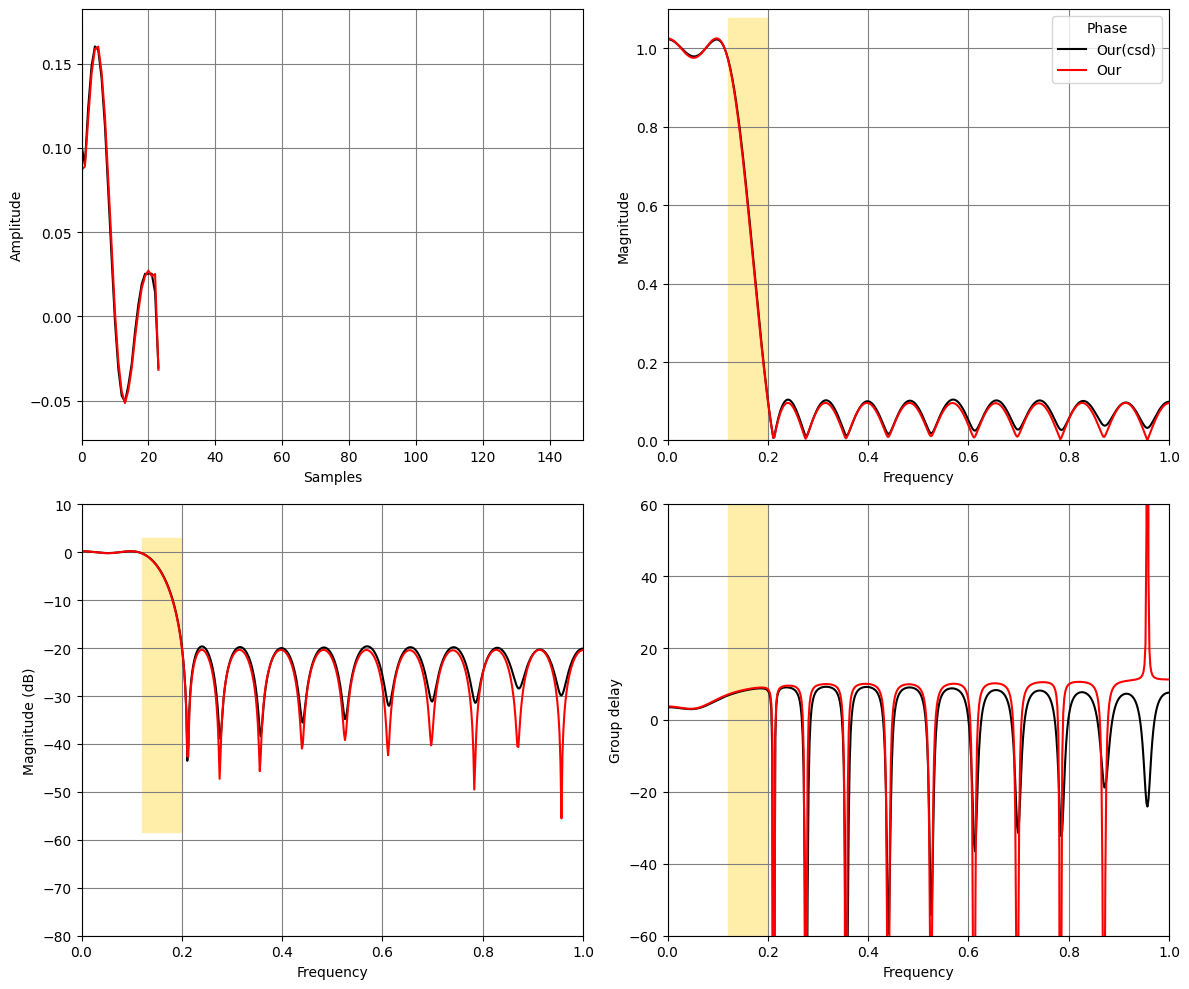

In [7]:
plot_lowpass_result(rf, Spsqf, rcsd, Spsqcsd)

## Summary

This notebook demonstrates:

1. **Standard FIR design** using spectral factorization + ellipsoid method
2. **CSD-constrained design** where coefficients are represented with limited non-zero digits

The CSD representation allows hardware implementation without multipliers (using shifts and adds instead).